In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import sklearn
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

In [2]:
# charger le dataset et le unziper
!unzip "/content/drive/MyDrive/data.zip" -d "/content/data"

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3336.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3346.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3355.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3366.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3404.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3405.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/341.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3417.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3454.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3461.jpg  
  inflating: /content/data/dl4cv-coin-classification (2)/kaggle/train/3466.jpg  
  inflating: /content/data/dl4cv

In [35]:
import os
from PIL import Image

# charger les données a utilisé
# on commence par crée la classe dataset pour manipuler les données image c'est tres recommendé
class My_dataset(Dataset):

  def __init__(self, image_dir, labels = None):
    self.image_dir = image_dir
    self.labels = labels
    self.images = sorted(os.listdir(image_dir), key=lambda x: int(os.path.splitext(x)[0]))  # tri numérique et va etre utilisé pour connaitre la taille du dataset
    self.transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
        img_name = self.images[index] # pour recuperer les nom des images comme ces dernieres ont les meme nom que les index
        img_path = os.path.join(self.image_dir, img_name) # le path vers l'image a la position index

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Erreur avec {img_path} : {e}")
            return None

        if self.transform:
          image = self.transform(image) # transformer l'image en tensor

        if self.labels is not None: # si données de train retourner image + labels
          try:
              img_id = int(os.path.splitext(img_name)[0])
              label = self.labels.loc[img_id] # pour pandas
              return image, torch.tensor(label, dtype=torch.long)
          except KeyError:
              print(f"Label manquant pour img_id={img_id}, image skippée")
              return None  # collate_fn va filtrer ce None

        else:
            return image, img_name # si test retourner l'image et sont nom(id)


In [36]:
# charger et remplacer les lebels par des nombre
labels_data = pd.read_csv("/content/data/dl4cv-coin-classification (2)/kaggle/train.csv")
labels = [labels_data.iloc[i, 1] for i in range(len(labels_data))]
labels_unique = set(labels)
label_transform = {label: int(idx) for idx, label in enumerate(labels_unique)}

labels_data = labels_data['Class'].apply(lambda x: label_transform[x])

In [37]:
labels_data

,Class
0,131
1,131
2,131
3,131
4,131
...,...
10361,76
10362,76
10363,76
10364,76


In [84]:
train_data = My_dataset("/content/data/dl4cv-coin-classification (2)/kaggle/train", labels_data)
test_data = My_dataset("/content/data/dl4cv-coin-classification (2)/kaggle/test")

In [102]:
from torch.utils.data import Subset
import random

# comme la dataset prend beacoup de temp sur l'entrainement de 60000 image on prend que 10000 images
indices = random.sample(range(len(train_data)), 2000)
train_subset = Subset(train_data, indices)

In [103]:
# maintenant on commence par extraire les données de validation
dataset_size = len(train_subset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(train_subset, [train_size, val_size])

In [104]:
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

In [105]:
train_loader = DataLoader(train_dataset,batch_size = 24, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 24, shuffle = False, collate_fn = collate_fn)
test_loader = DataLoader(test_data,batch_size = 24, shuffle = False, collate_fn = collate_fn)

In [106]:
class ModelCNN(nn.Module):
  def __init__(self):
    super(ModelCNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 96, kernel_size =11, stride = 4)
    # dans forward on mais les pooling
    self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 256, kernel_size =5, stride = 1)
    # une autre coche de pooling ici
    self.conv3 = nn.Conv2d(in_channels = 256, out_channels = 384, kernel_size =3, stride = 1)
    self.conv4 = nn.Conv2d(in_channels = 384, out_channels = 384, kernel_size =3, stride = 1)
    self.conv5 = nn.Conv2d(in_channels = 384, out_channels = 256, kernel_size =5, stride = 1)

    # maintenant les couche fully connected
    self.fc1 = nn.Linear(256, 4096)
    self.fc2 = nn.Linear(4096, 4096)
    self.out = nn.Linear(4096, len(label_transform))

  def forward(self, x):

    x = F.relu(self.conv1(x))
    x = F.max_pool2d(x, 2, 2)
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x, 2, 2)

    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = F.relu(self.conv5(x))
    x = F.max_pool2d(x, 2, 2)

    #flattening on utilise la formule suivante :O=S(I−K+2P)​+1 qu'on calcul pour chaque couche
    """
    O = taille de sortie (height ou width)
    I = taille d’entrée
    K = kernel size (taille du filtre)
    S = stride
    P = padding
    """
    x = x.view(x.size(0), -1) # calcul automatique

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x



In [107]:
model = ModelCNN()
print(model)

ModelCNN(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(384, 256, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=4096, bias=True)
  (fc2): Linear(in_features=4096, out_features=4096, bias=True)
  (out): Linear(in_features=4096, out_features=315, bias=True)
)


In [108]:
# maintenant definition de la fonction de loss
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9) # momentum : accelerer l'optimisation et stabilise l'apprentissage

In [109]:
epochs = 10
loss_list = []
accuracy_list = []

for epoch in range(epochs):
  running_loss = 0.0
  nb_data = 0.
  for i, data in enumerate(train_loader, 0):
    # extraire les données [image, lebel]
    if len(data) == 0:
      continue

    inputs, labels = data

    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # print statistics
    running_loss += loss.item()

    nb_data += 1

    # additionner les gradient avec zero_grad (comme ca les gradients vont pas etre recalculer a chaque fois)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  running_loss = running_loss / nb_data
  loss_list.append(running_loss)

  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for data in val_loader:
          inputs, labels = data
          outputs = model(inputs)

          _, predicted = torch.max(outputs, 1)  # classe avec le score le plus haut
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      accuracy = correct / total * 100
      accuracy_list.append(accuracy)

      print(f"Epoch {epoch+1}/{epochs} — Loss: {running_loss:.4f} — Val Accuracy: {accuracy:.2f}%")

  torch.save({
      'nb_epoch': epochs,
      'model': model.state_dict(),
      'listLoss': loss_list,
      'listAccuracy': accuracy_list,
  }, "modelNN.pth")
print('Finished Training and save the model as `modelNN.pth`')



Label manquant pour img_id=10756, image skippée
Label manquant pour img_id=10989, image skippée
Label manquant pour img_id=11004, image skippée
Label manquant pour img_id=10843, image skippée
Label manquant pour img_id=11291, image skippée
Label manquant pour img_id=10697, image skippée
Label manquant pour img_id=11155, image skippée
Label manquant pour img_id=11104, image skippée
Label manquant pour img_id=10452, image skippée
Label manquant pour img_id=11583, image skippée
Label manquant pour img_id=11058, image skippée
Label manquant pour img_id=11069, image skippée
Label manquant pour img_id=10872, image skippée
Label manquant pour img_id=11480, image skippée
Label manquant pour img_id=10492, image skippée
Label manquant pour img_id=11643, image skippée
Label manquant pour img_id=11393, image skippée
Label manquant pour img_id=10705, image skippée
Label manquant pour img_id=11055, image skippée
Label manquant pour img_id=10549, image skippée
Label manquant pour img_id=10674, image 

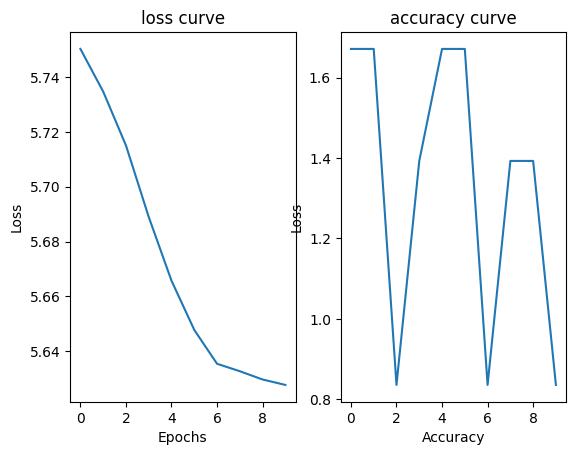

In [110]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.subplot(1,2,1)
plt.plot(range(len(loss_list)), loss_list)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("loss curve")

plt.subplot(1,2,2)
plt.plot(range(len(accuracy_list)), accuracy_list)

plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.title("accuracy curve")


plt.show()

In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [129]:
# Inverser le dictionnaire label_transform pour retrouver les noms de classes
inverse_label_transform = {v: k for k, v in label_transform.items()}

model.eval()
predictions = []

with torch.no_grad():
    for data in test_loader:
        if len(data) == 0:
            continue

        images, img_names = data
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        for img_name, pred in zip(img_names, predicted):
            if (len(predictions) >= 1282):
              break
            class_name = inverse_label_transform[pred.item()]
            image_id = os.path.splitext(img_name)[0]
            predictions.append({"Id": image_id, "Class": class_name})

# Sauvegarder les prédictions
submission = pd.DataFrame(predictions)
submission.to_csv("submission_final.csv", index=False)
print("Fichier submission.csv sauvegardé !")
print(submission.head(10))

Fichier submission.csv sauvegardé !
    Id                           Class
0   33  200 Dram,Armenian dram,Armenia
1   34  200 Dram,Armenian dram,Armenia
2   35  200 Dram,Armenian dram,Armenia
3   36  200 Dram,Armenian dram,Armenia
4   69  200 Dram,Armenian dram,Armenia
5   70  200 Dram,Armenian dram,Armenia
6   71  200 Dram,Armenian dram,Armenia
7   72  200 Dram,Armenian dram,Armenia
8  103  200 Dram,Armenian dram,Armenia
9  104  200 Dram,Armenian dram,Armenia


In [130]:
print(submission.shape)

(1282, 2)
